In [1]:
# Inspect signal scaling, temporal dependence, regional dependence, and PCA compression.
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

SEED = 28
cwd = Path.cwd()
ROOT = cwd if (cwd / "data" / "raw").exists() else cwd.parent
RAW = ROOT / "data" / "raw"
assert RAW.exists(), f"Could not find data/raw from {cwd}"
sns.set_theme(style="ticks", context="notebook")

In [2]:
def session_number(path):
    return int(re.search(r"ses-(\d+)", path.name).group(1))

files = sorted(RAW.glob("*.npy"), key=session_number)[:30]
sessions = []
for path in files:
    full = np.load(path).T
    valid = ~np.isnan(full).any(axis=1)
    sessions.append({"session": session_number(path), "full": full, "valid": valid, "x": full[valid]})

assert len(sessions) == 30
assert all(item["full"].shape == (820, 100) for item in sessions)
sum(len(item["x"]) for item in sessions)

24470

In [3]:
means = np.vstack([item["x"].mean(axis=0) for item in sessions])
sds = np.vstack([item["x"].std(axis=0, ddof=1) for item in sessions])
scale_ratio = sds.max(axis=1) / sds.min(axis=1)

moment_summary = pd.DataFrame({
    "metric": ["parcel mean", "parcel SD", "within-session max/min SD"],
    "minimum": [means.min(), sds.min(), scale_ratio.min()],
    "median": [np.median(means), np.median(sds), np.median(scale_ratio)],
    "maximum": [means.max(), sds.max(), scale_ratio.max()],
})
moment_summary.round(4)

,metric,minimum,median,maximum
0,parcel mean,-0.0151,-0.0000,0.0070
1,parcel SD,0.1254,0.3172,0.5925
2,within-session max/min SD,3.5677,3.9277,4.3820


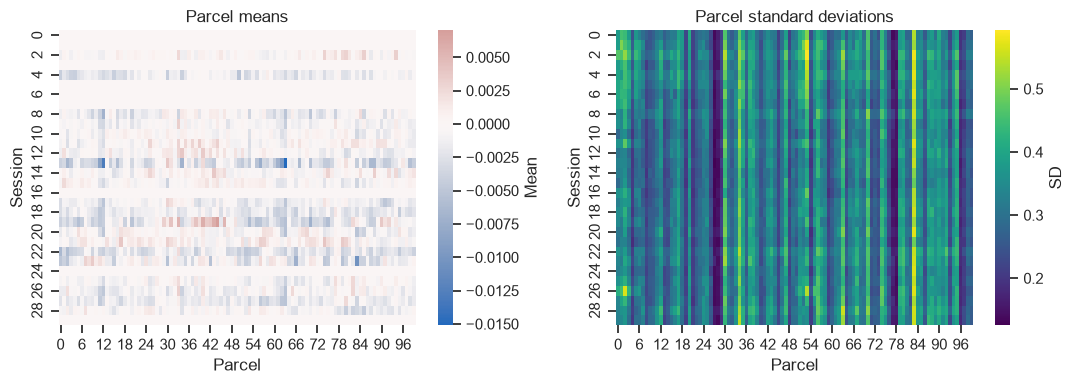

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(means, center=0, cmap="vlag", ax=axes[0], cbar_kws={"label": "Mean"})
sns.heatmap(sds, cmap="viridis", ax=axes[1], cbar_kws={"label": "SD"})
axes[0].set(title="Parcel means", xlabel="Parcel", ylabel="Session")
axes[1].set(title="Parcel standard deviations", xlabel="Parcel", ylabel="Session")
fig.tight_layout()

In [5]:
# Use only truly adjacent observed TR pairs; never bridge a motion gap.
lag1 = []
for item in sessions:
    adjacent = item["valid"][:-1] & item["valid"][1:]
    x0 = item["full"][:-1][adjacent]
    x1 = item["full"][1:][adjacent]
    lag1.append([np.corrcoef(x0[:, j], x1[:, j])[0, 1] for j in range(100)])
lag1 = np.asarray(lag1)

pd.Series(lag1.ravel(), name="lag-1 autocorrelation").describe(percentiles=[0.05, 0.25, 0.75, 0.95]).round(3)

count    3000.000
mean        0.708
std         0.131
min         0.214
5%          0.443
25%         0.632
75%         0.806
95%         0.864
max         0.934
Name: lag-1 autocorrelation, dtype: float64

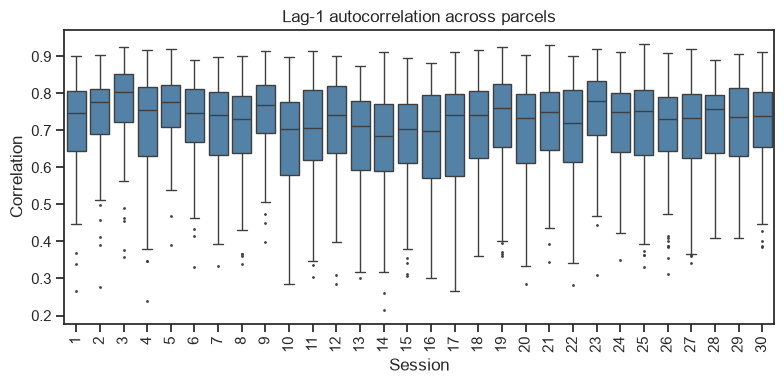

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=pd.DataFrame(lag1.T, columns=range(1, 31)), color="steelblue", fliersize=1, ax=ax)
ax.set(title="Lag-1 autocorrelation across parcels", xlabel="Session", ylabel="Correlation")
ax.tick_params(axis="x", labelrotation=90)
fig.tight_layout()

In [7]:
corr_matrices = np.stack([np.corrcoef(item["x"], rowvar=False) for item in sessions])
upper = np.triu_indices(100, k=1)
regional_r = corr_matrices[:, upper[0], upper[1]]

pd.DataFrame({
    "signed correlation": pd.Series(regional_r.ravel()).describe(percentiles=[0.05, 0.25, 0.75, 0.95]),
    "absolute correlation": pd.Series(np.abs(regional_r).ravel()).describe(percentiles=[0.05, 0.25, 0.75, 0.95]),
}).round(3)

,signed correlation,absolute correlation
count,148500.000,148500.000
mean,0.252,0.262
std,0.181,0.165
min,-0.493,0.000
5%,-0.031,0.031
25%,0.127,0.133
75%,0.367,0.367
95%,0.572,0.572
max,0.889,0.889


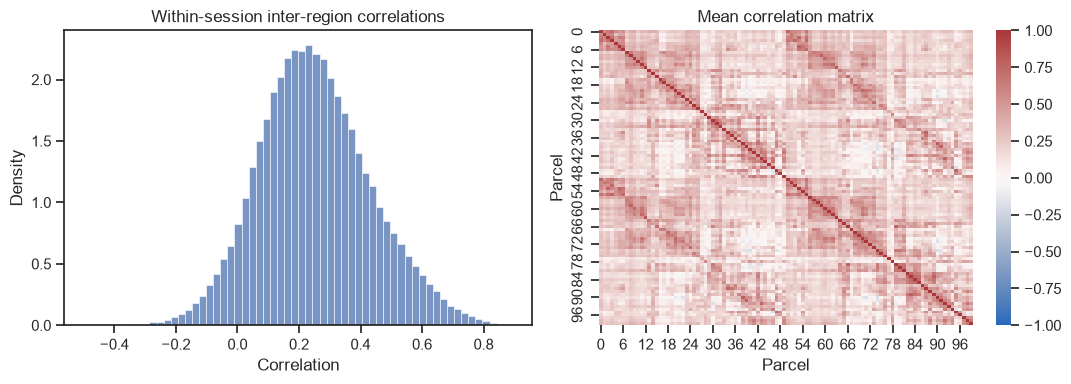

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(regional_r.ravel(), bins=60, stat="density", ax=axes[0])
sns.heatmap(corr_matrices.mean(axis=0), vmin=-1, vmax=1, center=0, cmap="vlag", ax=axes[1])
axes[0].set(title="Within-session inter-region correlations", xlabel="Correlation")
axes[1].set(title="Mean correlation matrix", xlabel="Parcel", ylabel="Parcel")
fig.tight_layout()

In [9]:
# Equalize parcel scales within session before fitting one shared PCA.
standardized = [(item["x"] - item["x"].mean(axis=0)) / item["x"].std(axis=0, ddof=1) for item in sessions]
z = np.vstack(standardized)
pca = PCA(svd_solver="full").fit(z)
cumulative = np.cumsum(pca.explained_variance_ratio_)
thresholds = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
pca_summary = pd.DataFrame({
    "variance retained": thresholds,
    "components": [np.searchsorted(cumulative, threshold) + 1 for threshold in thresholds],
})
pca_summary

,variance retained,components
0,0.50,5
1,0.60,8
2,0.70,13
3,0.80,24
4,0.85,34
5,0.90,47
6,0.95,66


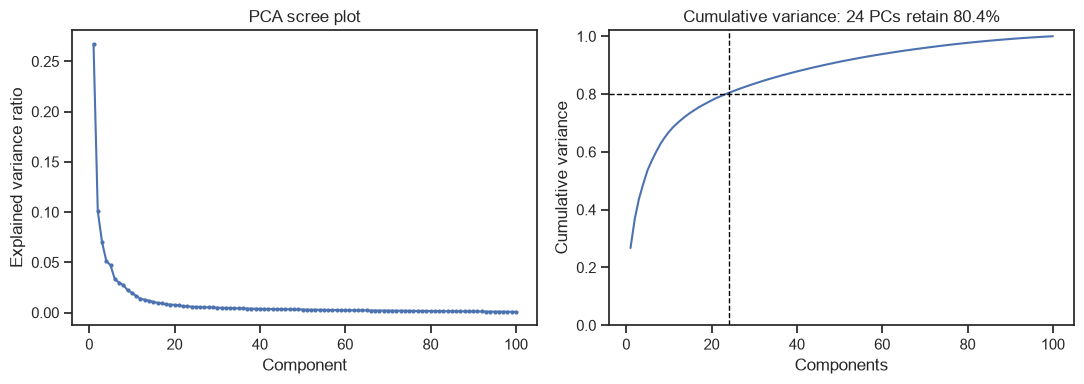

In [10]:
N_COMPONENTS = int(pca_summary.loc[pca_summary["variance retained"].eq(0.80), "components"].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, 101), pca.explained_variance_ratio_, marker=".", markersize=4)
axes[0].set(title="PCA scree plot", xlabel="Component", ylabel="Explained variance ratio")
axes[1].plot(range(1, 101), cumulative)
axes[1].axhline(0.80, color="black", linestyle="--", linewidth=1)
axes[1].axvline(N_COMPONENTS, color="black", linestyle="--", linewidth=1)
axes[1].set(title=f"Cumulative variance: {N_COMPONENTS} PCs retain {cumulative[N_COMPONENTS - 1]:.1%}", xlabel="Components", ylabel="Cumulative variance", ylim=(0, 1.02))
fig.tight_layout()

In [11]:
decision = pd.Series({
    "standardization": "z-score each parcel within each session using observed TRs",
    "scaling evidence": f"median within-session max/min SD ratio = {np.median(scale_ratio):.2f}",
    "primary representation": f"shared PCA with {N_COMPONENTS} components (>=80% variance)",
    "PCA evidence": f"median |regional r| = {np.median(np.abs(regional_r)):.2f}; {N_COMPONENTS}/100 PCs retain 80%",
    "final PCA fit": "fit once on concatenated standardized sessions 01-30",
    "model-selection PCA": "refit within each training fold to avoid leakage",
    "sensitivity analysis": "repeat key result using all 100 standardized parcels",
    "missing TRs": "retain gaps as sequence boundaries; do not interpolate",
}, name="preprocessing decision")
decision

standardization           z-score each parcel within each session using ...
scaling evidence              median within-session max/min SD ratio = 3.93
primary representation       shared PCA with 24 components (>=80% variance)
PCA evidence              median |regional r| = 0.24; 24/100 PCs retain 80%
final PCA fit             fit once on concatenated standardized sessions...
model-selection PCA        refit within each training fold to avoid leakage
sensitivity analysis      repeat key result using all 100 standardized p...
missing TRs               retain gaps as sequence boundaries; do not int...
Name: preprocessing decision, dtype: str